# Prepare Lorenz data for LSTM training

In [26]:
from math import ceil
import os
import random

import numpy
import torch

from forwardModel import forwardModel_r

if not os.path.exists(local_data_name := "lorenz_data4lstm.data"):
    random.seed(0)
    numpy.random.seed(0)
    torch.manual_seed(0)
    device = "cpu"

    # We define the control parameters here
    rayleigh = 35
    prandtl = 10.0
    b = 8.0 / 3.0
    # initial condition for the true reference trajectory
    x0 = torch.tensor([0.0, 1.0, 2.0], device=device)

    # integration time parameter
    dt = 1.0e-3  # This is time step size
    T = 500.0  # Total integration time, can be as short as 10 to speed things up
    n_steps = ceil(T / dt)
    time = torch.linspace(
        0.0, T, n_steps + 1, device=device
    )  # array of discrete times

    # numerical integration given initial conditions and control parameters
    xt = forwardModel_r(x0, time, rayleigh, prandtl, b)

    print(f"{xt.shape=}, {xt.dtype=}")

    torch.save(xt.T, local_data_name)
    data = torch.load(local_data_name)

    print(f"{torch.allclose(data, xt.T)=}")

# Setup random device and seed

In [27]:
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from livelossplot import PlotLosses
import matplotlib.pyplot as plt
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")


def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = True


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    numpy.random.seed(worker_seed)
    random.seed(worker_seed)


def set_device():
    """
    Use CPU if cuda device is not available
    setup tf32 for faster GPU computation
    """
    if torch.cuda.device_count() == 0:
        return "cpu"
    torch.set_float32_matmul_precision("high")
    return "cuda"


set_seed(0)
g = torch.Generator()
g.manual_seed(0)

# Customized Network Architecture

In [28]:
class LSTM_1TON(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, out_seq_length):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.out_seq_length = out_seq_length

        self.fc_in = nn.Linear(input_dim, hidden_dim)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor):
        x_inner = x.view(1, 1, -1) if x.ndim in (1, 2) else x
        x0 = self.fc_in(x)
        hn = x0.clone().view(1, x_inner.size(0), self.hidden_dim).repeat(self.num_layers, 1, 1)
        cn = hn.clone()
        outs = [0] * self.out_seq_length
        for i in range(self.out_seq_length):
            x_inner, (hn, cn) = self.lstm(x_inner, (hn, cn))
            x_inner = self.fc(F.elu(x_inner))
            outs[i] = x_inner
        ret = torch.cat(outs, dim=1)
        return ret.squeeze_(0) if x.ndim in (1, 2) else ret

# Define how to feed data

In [29]:
class SeqDataset(Dataset):
    def __init__(self, valid_ratio=0.01, seq_length=1):
        self.seq_length = seq_length
        # default `u` path is `data/u/`
        self.data = torch.load("lorenz_data4lstm.data")
        num_all_samples = self.data.size(0)
        # keep indices sequential
        slice_idx = int(valid_ratio * num_all_samples)
        self.train_data = self.data[:-slice_idx]
        self.valid_data = self.data[-slice_idx:]
        self.train()

    def train(self):
        # total number of samples counted by sliding the training sample window forward 1 step each time
        self.num_samples = len(self.train_data) - 2 * self.seq_length + 1
        self.idxs = self.train_data

    def eval(self):
        # total number of samples counted by sliding the training sample window forward 1 step each time
        self.num_samples = len(self.valid_data) - 2 * self.seq_length + 1
        self.idxs = self.valid_data

    def __len__(self):
        return self.num_samples

    def __getitem__(self, i):
        # get model input and predict samples at the same time
        # (model input --> samples[:seq_length], predict --> samples[seq_length:])
        # for j in range(i, i + 2 * self.seq_length):
        #     print(os.path.join(self.imgs_folder_path, f"{self.idxs[j]}.png"))
        return self.idxs[i:i + 2 * self.seq_length]

# Initialize model

In [30]:
lstm_model = LSTM_1TON(3, 12, 20, 3, 99)
sum(p.numel() for p in lstm_model.parameters())

24615

# Training steps

In [31]:
def train_LSTM_model(data, lstm_model, epochs, device="cpu"):
    lstm_model = lstm_model.to(device)
    optimizer = torch.optim.Adam(lstm_model.parameters(), lr=7.5e-3)
    liveloss = PlotLosses(groups={"Loss": ["train loss", "valid loss"]})
    for _ in range(epochs):
        train_loss, valid_loss = 0, 0
        lstm_model.train()
        data.train()
        for seqs in DataLoader(
            dataset=data, batch_size=2048, shuffle=True, num_workers=4
        ):
            seqs = seqs.to(device)
            # use encoder to get latent vectors
            # training step
            seqs, out_seqs = seqs[:, :1], seqs[:, 1:]
            optimizer.zero_grad(set_to_none=True)
            out = lstm_model(seqs)
            loss = F.mse_loss(out, out_seqs, reduction="sum")
            loss.backward()
            optimizer.step()
            # accumulate for average train loss
            train_loss += loss
        # calculate average train loss
        avg_train_loss = (train_loss / len(data)).item()
        # switch to eval mode
        lstm_model.eval()
        data.eval()
        with torch.no_grad():
            for seqs in DataLoader(
                dataset=data, batch_size=8192, shuffle=False, num_workers=4
            ):
                seqs = seqs.to(device)
                # eval step
                seqs, out_seqs = seqs[:, :1], seqs[:, 1:]
                out = lstm_model(seqs)
                loss = F.mse_loss(out, out_seqs, reduction="sum")
                # accumulate for average valid loss
                valid_loss += loss
        # update plot
        logs = {
            "train loss": avg_train_loss,
            "valid loss": (valid_loss / len(data)).item(),
        }
        liveloss.update(logs)
        liveloss.draw()
    return lstm_model


lstm_data = SeqDataset(seq_length=50)
# save parameters to save training time
lstm_model_name = "lstm4lorenz_model_1to99_100ep.pt"
if os.path.exists(lstm_model_name):
    lstm_model.load_state_dict(torch.load(lstm_model_name, map_location="cpu"))
else:
    device = set_device()
    lstm_model = train_LSTM_model(lstm_data, lstm_model, epochs=100, device=device)
    torch.save(lstm_model.state_dict(), lstm_model_name)
device = "cpu"

/tmp/ipykernel_382333/1475002256.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data = torch.load("lorenz_data4lstm.data")
/tmp/ipykernel_382333/495772115.py:53: F

# Construct observations in a time window

In [32]:
from torchda import apply_KF, apply_EnKF

In [33]:
# We define the control parameters here
rayleigh = 35
prandtl = 10.
b = 8./3.
# initial condition for the true reference trajectory
x0 = torch.tensor([0., 1., 2.], device=device)

# integration time parameter
dt = 1.e-3      # This is time step size
T = 25.         # Total integration time, can be as short as 10 to speed things up
num_steps = ceil(T / dt)
time = torch.linspace(0., T, num_steps + 1, device=device)  # array of discrete times

# numerical integration given initial conditions and control parameters
xt = forwardModel_r(x0, time, rayleigh, prandtl, b)

In [34]:
# Which variables do we observe?
WhichVariablesAreObserved = torch.tensor([1, 1, 1])
#  Determines which variables are available to
#  the EnKF. For example:
#  WhichVariablesAreObserved = [1 1 1];
#  means: X, Y, Z are observed
#  WhichVariablesAreObserved = [1 0 1];
#  means: X and Z are observed
#  WhichVariablesAreObserved = [1 0 0];
# means: X is observed
# We generate the synthetic data
#  Construct observation matrix H
#  ........................................................................
y_size = int(WhichVariablesAreObserved.sum())
# Callable H
def H(x: torch.Tensor):
    h = torch.zeros((y_size, 3), device=device)
    iy = 0
    for ix in range(3):
        if WhichVariablesAreObserved[ix] > 0:
            h[iy, ix] = 1.
            iy += 1
    return h @ x
# # Tensor H
# H = torch.zeros((y_size, 3), device=device)
# iy = 0
# for ix in range(3):
#     if WhichVariablesAreObserved[ix] > 0:
#         H[iy, ix] = 1.
#         iy += 1

## Four experimental settings for the standard deviation of the observation noise (`sigobs`) and the standard deviation of the background noise (`sigens`)
### 1) `sigobs = 0.5 * sigens`

In [35]:
# How often do we observe the true state?
dtobs = 0.5  # time between observations
# no observation at t=0
gap = int(dtobs / dt)  # number of time steps between each observation
time_obs = time[gap::gap]
# Generate vector of observations
sigobs = 0.5  # standard deviation of the observation noise
R = (sigobs**2) * torch.eye(y_size, device=device)
sqrt_s = torch.sqrt(R)
# y = Hxt
y = H @ xt[:, gap::gap] if isinstance(H, torch.Tensor) else H(xt[:, gap::gap])
# compute observation error
noise = sqrt_s @ torch.randn(size=y.shape, device=device)
# y = Hxt + epsilon
y = y + noise

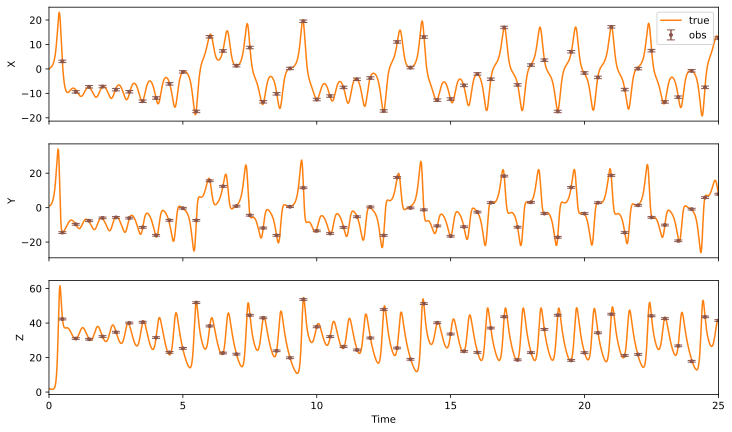

In [36]:
# Plot reference trajectory and the observations that will be fed to the EnKF
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
# fig.suptitle('Reference trajectory + observations')
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Forward prediction test without EnKF

In [37]:
lstm_model = lstm_model.to(device)
lstm_model.eval()

LSTM_1TON(
  (fc_in): Linear(in_features=3, out_features=12, bias=True)
  (lstm): LSTM(3, 12, num_layers=20, batch_first=True)
  (fc): Linear(in_features=12, out_features=3, bias=True)
)

In [38]:
xtT = xt.T
print(f"{xtT.shape=}")
lstm_outs = [xtT0.view(1, -1) if (xtT0:=xtT[0]).ndim == 1 else xtT0]
next_in = lstm_outs[0]
with torch.no_grad():
    forward_times, residue = divmod(xtT.size(0)-1, lstm_model.out_seq_length)
    for _ in range(forward_times+1):
        outs = lstm_model(next_in)
        lstm_outs.append(outs)
        next_in = outs[-1]
    lstm_outs[-1] = lstm_outs[-1][:residue]
    lstm_outs = torch.cat(lstm_outs).T
lstm_outs.shape

xtT.shape=torch.Size([25001, 3])


torch.Size([3, 25001])

In [39]:
# Compute Euclidean error wrt true state which is known in this synthetic game
# cumulative error
cum_error_comp = torch.sum((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
cum_error = torch.sum(cum_error_comp)
norm_comp = torch.sum(xt**2, dim=1)
norm = torch.sum(xt**2)
print("No DA Relative errors (RRMSE) in %")
for k, comp in enumerate(["X", "Y", "Z"]):
    print(f"{comp}-component: {100.0 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.1f}")
print(f"3-component: {100.0 * torch.sqrt(cum_error / norm):.1f}\n")
print("No DA Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt - lstm_outs.detach().numpy()) ** 2):.1f}")

No DA Relative errors (RRMSE) in %
X-component: 125.5
Y-component: 124.7
Z-component: 40.9
3-component: 62.3

No DA Relative errors (MSE) in %
3-component: 16111.2


/tmp/ipykernel_382333/1681304420.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cum_error_comp = torch.sum((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
/tmp/ipykernel_382333/1681304420.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"3-component: {100.0 * torch.mean((xt - lstm_outs.detach().numpy()) ** 2):.1f}")


/tmp/ipykernel_382333/1963533532.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cum_error_comp = torch.sum((xt - lstm_outs.detach().numpy()) ** 2, dim=1)


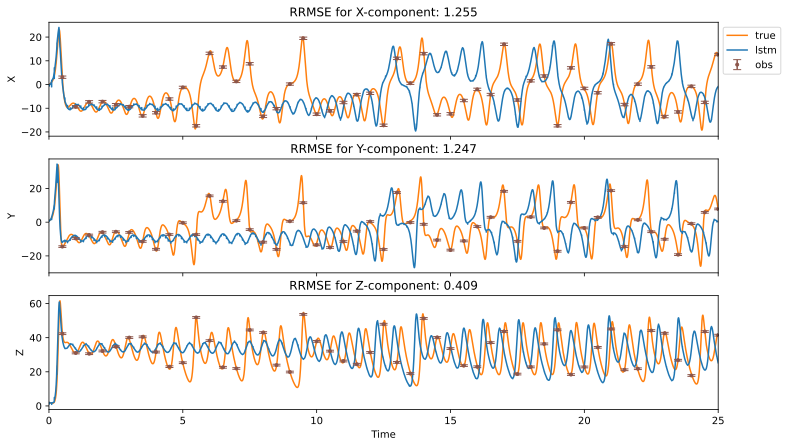

In [40]:
# cum_error_comp = torch.mean((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
cum_error_comp = torch.sum((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
norm_comp = torch.sum(xt**2, dim=1)
# Plot reference trajectory and the observations that will be fed to the EnKF
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    ax[k].plot(time.cpu(), lstm_outs.detach().numpy()[k, :], color="#1f77b4", label='lstm')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}%"
        f"RRMSE for {comp}-component: {torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}"
    )
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Forward prediction test with EnKF

In [41]:
# Initialization of the Ensemble
Ne = 50  # Number of ensemble members
sigens = 1.  # standard deviation of the ensemble
# initial covariance matrix
P0 = (sigens**2)*torch.eye(3, device=device)

## Recall that we generated a vector of observations before
```python
sigobs = 0.5  # standard deviation of the observation noise
R = (sigobs**2) * torch.eye(y_size, device=device)
sqrt_s = torch.sqrt(R)
# y = Hxt
y = H @ xt[:, gap::gap] if isinstance(H, torch.Tensor) else H(xt[:, gap::gap])
# compute observation error
noise = sqrt_s @ torch.randn(size=y.shape, device=device)
# y = Hxt + epsilon
y = y + noise
```

In [42]:
# Callable H
def H(x: torch.Tensor):
    h = torch.zeros((y_size, 3), device=device) 
    iy = 0
    for ix in range(3):
        if WhichVariablesAreObserved[ix] > 0:
            h[iy, ix] = 1.
            iy += 1
    return x @ h.T
# H = torch.randn((y_size, 3), device=device)
# # Tensor H
# H = torch.zeros((y_size, 3), device=device)
# iy = 0
# for ix in range(3):
#     if WhichVariablesAreObserved[ix] > 0:
#         H[iy, ix] = 1.
#         iy += 1

In [43]:
# Now we run the EnKF
gaps = [gap] * len(time_obs)
# xEnKF, x_ens = apply_EnKF(
#     time_obs, gaps, Ne, M, H, P0, R, xtT[0], y.T
# )
# xEnKF, x_ens = xEnKF.T, x_ens.transpose(0, -1)

In [44]:
import torchda

parameters = torchda.Parameters(
    algorithm=torchda.Algorithms.EnKF,
    device=torchda.Device.CPU,
    observation_time_steps=time_obs,
    gaps=gaps,
    num_ensembles=Ne,
    observation_model=H,
    output_sequence_length=lstm_model.out_seq_length,
    forward_model=lstm_model,
    background_covariance_matrix=P0,
    observation_covariance_matrix=R,
    background_state=xtT[0],
    observations=y.T,
)

run_case = torchda.CaseBuilder(parameters=parameters)

if parameters.device is torchda.Device.GPU:

    def H(x: torch.Tensor):
        h = torch.zeros((y_size, 3), device="cuda")
        iy = 0
        for ix in range(3):
            if WhichVariablesAreObserved[ix] > 0:
                h[iy, ix] = 1.
                iy += 1
        return x @ h.T

    run_case.set_observation_model(H)

enkf_res = "xEnKF_100ep.case_one.data"
all_enkf_res = "x_ens_100ep.case_one.data"
if not (os.path.exists(enkf_res) and os.path.exists(all_enkf_res)):
    results = run_case.execute()
    xEnKF, x_ens = results["average_ensemble_all_states"].T.to("cpu"), results["each_ensemble_all_states"].transpose(0, -1).to("cpu")
    torch.save(xEnKF, enkf_res)
    torch.save(x_ens, all_enkf_res)
else:
    xEnKF = torch.load(enkf_res, map_location="cpu")
    x_ens = torch.load(all_enkf_res, map_location="cpu")

/tmp/ipykernel_382333/3560587534.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  xEnKF = torch.load(enkf_res, map_location="cpu")
/tmp/ipykernel_382333/3560587534.py:42

In [45]:
# Compute Euclidean error wrt true state which is known in this synthetic game
# cumulative error
# cum_error_comp = torch.sqrt(torch.sum((xt - x_estimates) ** 2, dim=1))
cum_error_comp = torch.sum((xt - xEnKF) ** 2, dim=1)
cum_error = torch.sum(cum_error_comp)
norm_comp = torch.sum(xt**2, dim=1)
norm = torch.sum(xt**2)
print("EnKF Relative errors (RRMSE) in %")
for k, comp in enumerate(["X", "Y", "Z"]):
    print(f"{comp}-component: {100.0 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.1f}")
print(f"3-component: {100.0 * torch.sqrt(cum_error / norm):.1f}\n")
print("EnKF Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt - xEnKF) ** 2):.1f}")

EnKF Relative errors (RRMSE) in %
X-component: 33.5
Y-component: 44.1
Z-component: 10.5
3-component: 18.6

EnKF Relative errors (MSE) in %
3-component: 1434.8


In [46]:
all_3component_error = []
for e in range(Ne):
    cum_error_comp_one = torch.sum((xt - x_ens[:, e]) ** 2, dim=1)
    cum_error_one = torch.sum(cum_error_comp_one)
    all_3component_error.append(float(100.0 * torch.sqrt(cum_error_one / norm)))
print(f"max error in all components: {max(all_3component_error)}%")

max error in all components: 25.30963706970215%


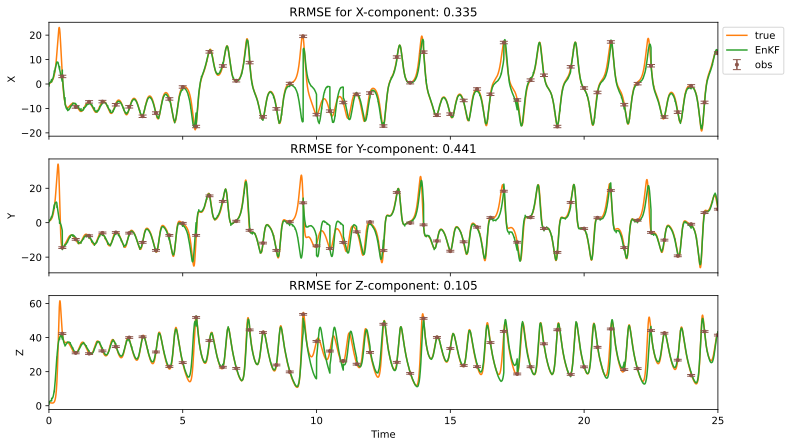

In [47]:
# Plot results
# cum_error_comp = torch.mean((xt - xEnKF) ** 2, dim=1)
cum_error_comp = torch.sum((xt - xEnKF) ** 2, dim=1)
norm_comp = torch.sum(xt**2, dim=1)
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    ax[k].plot(time.cpu(), xEnKF.cpu()[k, :], color="#2ca02c", label='EnKF')
    # ax[k].plot(time.cpu(), x_estimates.cpu()[k, :], label='EnKF')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        iobs += 1
    # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}%"
        f"RRMSE for {comp}-component: {torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}"
    )
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Background state assimilation with 4DVar

In [48]:
start_time_point, end_time_point = 17, 20
gaps = [gap] * (y.T[start_time_point:end_time_point].size(0) - 1)
lstm_model = lstm_model.train()

parameters = torchda.Parameters(
    algorithm=torchda.Algorithms.Var4D,
    device=torchda.Device.GPU,
    observation_time_steps=time_obs[start_time_point:end_time_point],
    gaps=gaps,
    observation_model=H,
    output_sequence_length=lstm_model.out_seq_length,
    forward_model=lstm_model,
    background_covariance_matrix=P0,
    observation_covariance_matrix=R,
    background_state=y.T[start_time_point],
    observations=y.T,
    optimizer_cls=torch.optim.Adam,
    optimizer_args={"lr": 0.5},
    max_iterations=200
)

run_case = torchda.CaseBuilder().set_parameters(parameters)

if parameters.device is torchda.Device.GPU:

    def H(x: torch.Tensor):
        h = torch.zeros((y_size, 3), device="cuda")
        iy = 0
        for ix in range(3):
            if WhichVariablesAreObserved[ix] > 0:
                h[iy, ix] = 1.
                iy += 1
        return x @ h.T

    run_case.set_observation_model(H)

var4d_res = "4dvar.case_one.data"
if not os.path.exists(var4d_res):
    results = run_case.execute()
    x0 = results["assimilated_state"]
    torch.save(x0, var4d_res)
else:
    x0 = torch.load(var4d_res, map_location="cpu")

/tmp/ipykernel_382333/1499539216.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x0 = torch.load(var4d_res, map_location="cpu")


In [24]:
x0 = x0.to(device)
lstm_model = lstm_model.to(device)
outs = [xb.view(1, -1) if (xb:=x0).ndim == 1 else x0]
x = outs[0]
start_end_time = time_obs[start_time_point:end_time_point]
for i in range(1, len(start_end_time)):
    time_fw = torch.linspace(start_end_time[i-1], start_end_time[i], gap+1)
    forward_times, residue = divmod(len(time_fw[:-1]), lstm_model.out_seq_length)
    for _ in range(forward_times+1):
        x = lstm_model(x)
        outs.append(x)
        x = x[-1]
    outs[-1] = outs[-1][:residue]
outs = torch.cat(outs).T

In [25]:
time_idxs = [
    i
    for i, t in enumerate(time)
    if t in time_obs[start_time_point:end_time_point]
]
var4d_times = time[time_idxs[0]:time_idxs[-1]+1]

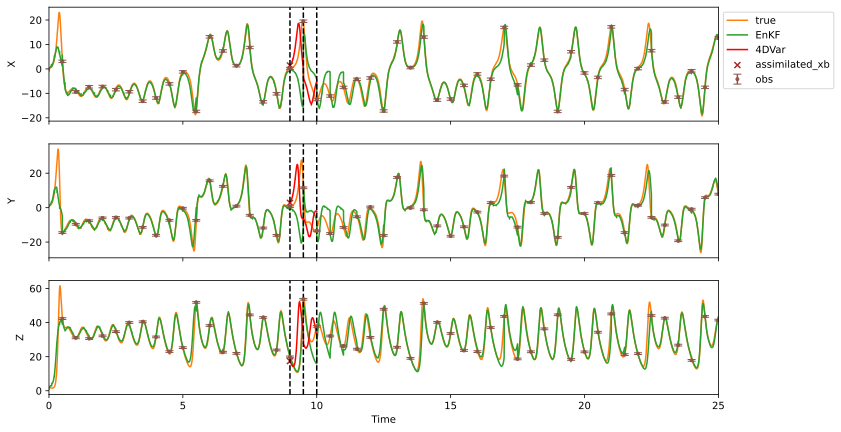

In [26]:
# Plot results
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    # ax[k].plot(time.cpu(), lstm_outs.detach().numpy()[k, :], color="#1f77b4", label='lstm')
    ax[k].plot(time.cpu(), xEnKF.cpu()[k, :], color="#2ca02c", label='EnKF')
    ax[k].plot(var4d_times.cpu(), outs.detach().numpy()[k, :], color="red", label='4DVar')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        ax[k].scatter(time_obs[start_time_point].cpu(), x0.cpu()[k],
                      color="brown", marker="x", label='assimilated_xb')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    for x in time_obs[start_time_point:end_time_point]:
        ax[k].axvline(x, color="k", linestyle="--")
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

In [27]:
noda_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - lstm_outs.detach().numpy()[:, time_idxs[0]:time_idxs[-1]+1]) ** 2)
enkf_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2)
var4d_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2)
norm = torch.sum(xt[:, time_idxs[0]:time_idxs[-1]+1]**2)
print("Relative errors (RRMSE) in %")
print(f"3-component: {100.0 * torch.sqrt(noda_cum_error / norm):.1f} (No DA)")
print(f"3-component: {100.0 * torch.sqrt(enkf_cum_error / norm):.1f} (EnKF)")
print(f"3-component: {100.0 * torch.sqrt(var4d_cum_error / norm):.1f} (4DVar)\n")
print("Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - lstm_outs.detach().numpy()[:, time_idxs[0]:time_idxs[-1]+1]) ** 2):.1f} (No DA)")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2):.1f} (EnKF)")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2):.1f} (4DVar)")

Relative errors (RRMSE) in %
3-component: 79.0 (No DA)
3-component: 67.7 (EnKF)
3-component: 68.1 (4DVar)

Relative errors (MSE) in %
3-component: 24146.6 (No DA)
3-component: 17746.2 (EnKF)
3-component: 17949.9 (4DVar)


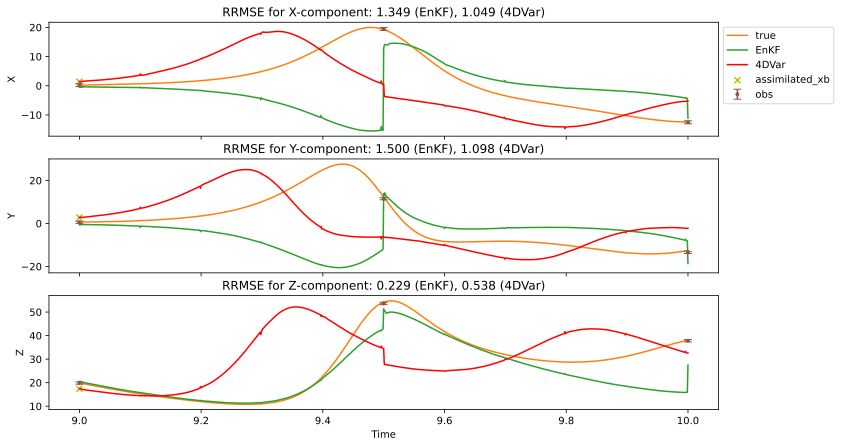

In [28]:
# Plot results
enkf_cum_error_comp = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2, dim=1)
# enkf_cum_error_comp = torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2, dim=1)
var4d_cum_error_comp = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2, dim=1)
# var4d_cum_error_comp = torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2, dim=1)
norm_comp = torch.sum(xt[:, time_idxs[0]:time_idxs[-1]+1]**2, dim=1)
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(var4d_times.cpu(), xt.cpu()[k, time_idxs[0]:time_idxs[-1]+1], color="#ff7f0e", label='true')
    # ax[k].plot(var4d_times.cpu(), lstm_outs.detach().numpy()[k, time_idxs[0]:time_idxs[-1]+1], color="#1f77b4", label='lstm')
    ax[k].plot(var4d_times.cpu(), xEnKF.cpu()[k, time_idxs[0]:time_idxs[-1]+1], color="#2ca02c", label='EnKF')
    ax[k].plot(var4d_times.cpu(), outs.detach().numpy()[k, :], color="red", label='4DVar')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu()[start_time_point:end_time_point], y.cpu()[iobs, start_time_point:end_time_point],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        ax[k].scatter(time_obs[start_time_point].cpu(), x0.cpu()[k],
                      color="y", marker="x", label='assimilated_xb')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(enkf_cum_error_comp[k] / norm_comp[k]):.3f}% (EnKF), {100 * torch.sqrt(var4d_cum_error_comp[k] / norm_comp[k]):.3f}% (4DVar)"
        f"RRMSE for {comp}-component: {torch.sqrt(enkf_cum_error_comp[k] / norm_comp[k]):.3f} (EnKF), {torch.sqrt(var4d_cum_error_comp[k] / norm_comp[k]):.3f} (4DVar)"
    )
ax[-1].set_xlabel('Time')
# ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

### 2) `sigobs = 1.0 * sigens`

In [29]:
torch.cuda.empty_cache()

# Construct observations in a time window

In [30]:
# We define the control parameters here
rayleigh = 35
prandtl = 10.
b = 8./3.
# initial condition for the true reference trajectory
x0 = torch.tensor([0., 1., 2.], device=device)

# integration time parameter
dt = 1.e-3      # This is time step size
T = 25.         # Total integration time, can be as short as 10 to speed things up
num_steps = ceil(T / dt)
time = torch.linspace(0., T, num_steps + 1, device=device)  # array of discrete times

# numerical integration given initial conditions and control parameters
xt = forwardModel_r(x0, time, rayleigh, prandtl, b)

In [31]:
# Which variables do we observe?
WhichVariablesAreObserved = torch.tensor([1, 1, 1])
#  Determines which variables are available to
#  the EnKF. For example:
#  WhichVariablesAreObserved = [1 1 1];
#  means: X, Y, Z are observed
#  WhichVariablesAreObserved = [1 0 1];
#  means: X and Z are observed
#  WhichVariablesAreObserved = [1 0 0];
# means: X is observed
# We generate the synthetic data
#  Construct observation matrix H
#  ........................................................................
y_size = int(WhichVariablesAreObserved.sum())
# Callable H
def H(x: torch.Tensor):
    h = torch.zeros((y_size, 3), device=device)
    iy = 0
    for ix in range(3):
        if WhichVariablesAreObserved[ix] > 0:
            h[iy, ix] = 1.
            iy += 1
    return h @ x
# # Tensor H
# H = torch.zeros((y_size, 3), device=device)
# iy = 0
# for ix in range(3):
#     if WhichVariablesAreObserved[ix] > 0:
#         H[iy, ix] = 1.
#         iy += 1

In [32]:
# How often do we observe the true state?
dtobs = 0.5  # time between observations
# no observation at t=0
gap = int(dtobs / dt)  # number of time steps between each observation
time_obs = time[gap::gap]
# Generate vector of observations
sigobs = 1.0  # standard deviation of the observation noise
R = (sigobs**2) * torch.eye(y_size, device=device)
sqrt_s = torch.sqrt(R)
# y = Hxt
y = H @ xt[:, gap::gap] if isinstance(H, torch.Tensor) else H(xt[:, gap::gap])
# compute observation error
noise = sqrt_s @ torch.randn(size=y.shape, device=device)
# y = Hxt + epsilon
y = y + noise

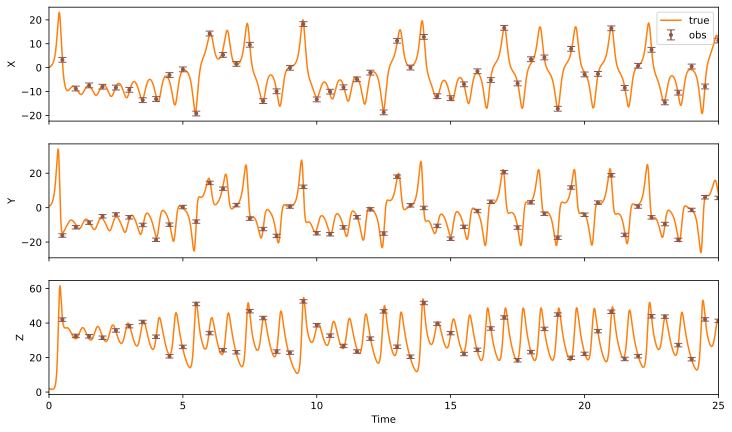

In [33]:
# Plot reference trajectory and the observations that will be fed to the EnKF
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
# fig.suptitle('Reference trajectory + observations')
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Forward prediction test without EnKF

In [34]:
lstm_model = lstm_model.to(device)
lstm_model.eval()

LSTM_1TON(
  (fc_in): Linear(in_features=3, out_features=12, bias=True)
  (lstm): LSTM(3, 12, num_layers=20, batch_first=True)
  (fc): Linear(in_features=12, out_features=3, bias=True)
)

In [35]:
xtT = xt.T
print(f"{xtT.shape=}")
lstm_outs = [xtT0.view(1, -1) if (xtT0:=xtT[0]).ndim == 1 else xtT0]
next_in = lstm_outs[0]
with torch.no_grad():
    forward_times, residue = divmod(xtT.size(0)-1, lstm_model.out_seq_length)
    for _ in range(forward_times+1):
        outs = lstm_model(next_in)
        lstm_outs.append(outs)
        next_in = outs[-1]
    lstm_outs[-1] = lstm_outs[-1][:residue]
    lstm_outs = torch.cat(lstm_outs).T
lstm_outs.shape

xtT.shape=torch.Size([25001, 3])


torch.Size([3, 25001])

In [36]:
# Compute Euclidean error wrt true state which is known in this synthetic game
# cumulative error
cum_error_comp = torch.sum((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
cum_error = torch.sum(cum_error_comp)
norm_comp = torch.sum(xt**2, dim=1)
norm = torch.sum(xt**2)
print("No DA Relative errors (RRMSE) in %")
for k, comp in enumerate(["X", "Y", "Z"]):
    print(f"{comp}-component: {100.0 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.1f}")
print(f"3-component: {100.0 * torch.sqrt(cum_error / norm):.1f}\n")
print("No DA Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt - lstm_outs.detach().numpy()) ** 2):.1f}")

No DA Relative errors (RRMSE) in %
X-component: 125.7
Y-component: 123.4
Z-component: 40.3
3-component: 61.8

No DA Relative errors (MSE) in %
3-component: 15831.1


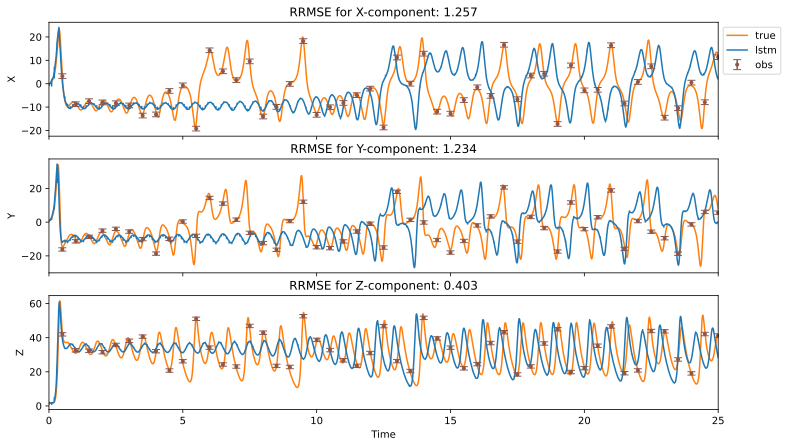

In [37]:
# cum_error_comp = torch.mean((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
cum_error_comp = torch.sum((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
norm_comp = torch.sum(xt**2, dim=1)
# Plot reference trajectory and the observations that will be fed to the EnKF
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    ax[k].plot(time.cpu(), lstm_outs.detach().numpy()[k, :], color="#1f77b4", label='lstm')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}%"
        f"RRMSE for {comp}-component: {torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}"
    )
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Forward prediction test with EnKF

In [38]:
# Initialization of the Ensemble
Ne = 50  # Number of ensemble members
sigens = 1.  # standard deviation of the ensemble
# initial covariance matrix
P0 = (sigens**2)*torch.eye(3, device=device)

## Recall that we generated a vector of observations before
```python
sigobs = 1.0  # standard deviation of the observation noise
R = (sigobs**2) * torch.eye(y_size, device=device)
sqrt_s = torch.sqrt(R)
# y = Hxt
y = H @ xt[:, gap::gap] if isinstance(H, torch.Tensor) else H(xt[:, gap::gap])
# compute observation error
noise = sqrt_s @ torch.randn(size=y.shape, device=device)
# y = Hxt + epsilon
y = y + noise
```

In [39]:
# Callable H
def H(x: torch.Tensor):
    h = torch.zeros((y_size, 3), device=device) 
    iy = 0
    for ix in range(3):
        if WhichVariablesAreObserved[ix] > 0:
            h[iy, ix] = 1.
            iy += 1
    return x @ h.T
# H = torch.randn((y_size, 3), device=device)
# # Tensor H
# H = torch.zeros((y_size, 3), device=device)
# iy = 0
# for ix in range(3):
#     if WhichVariablesAreObserved[ix] > 0:
#         H[iy, ix] = 1.
#         iy += 1

In [40]:
# Now we run the EnKF
gaps = [gap] * len(time_obs)
# xEnKF, x_ens = apply_EnKF(
#     time_obs, gaps, Ne, M, H, P0, R, xtT[0], y.T
# )
# xEnKF, x_ens = xEnKF.T, x_ens.transpose(0, -1)

In [41]:
import torchda

parameters = torchda.Parameters(
    algorithm=torchda.Algorithms.EnKF,
    device=torchda.Device.CPU,
    observation_time_steps=time_obs,
    gaps=gaps,
    num_ensembles=Ne,
    observation_model=H,
    output_sequence_length=lstm_model.out_seq_length,
    forward_model=lstm_model,
    background_covariance_matrix=P0,
    observation_covariance_matrix=R,
    background_state=xtT[0],
    observations=y.T,
)

run_case = torchda.CaseBuilder(parameters=parameters)

if parameters.device is torchda.Device.GPU:

    def H(x: torch.Tensor):
        h = torch.zeros((y_size, 3), device="cuda")
        iy = 0
        for ix in range(3):
            if WhichVariablesAreObserved[ix] > 0:
                h[iy, ix] = 1.
                iy += 1
        return x @ h.T

    run_case.set_observation_model(H)

enkf_res = "xEnKF_100ep.case_two.data"
all_enkf_res = "x_ens_100ep.case_two.data"
if not (os.path.exists(enkf_res) and os.path.exists(all_enkf_res)):
    results = run_case.execute()
    xEnKF, x_ens = results["average_ensemble_all_states"].T.to("cpu"), results["each_ensemble_all_states"].transpose(0, -1).to("cpu")
    torch.save(xEnKF, enkf_res)
    torch.save(x_ens, all_enkf_res)
else:
    xEnKF = torch.load(enkf_res, map_location="cpu")
    x_ens = torch.load(all_enkf_res, map_location="cpu")

In [42]:
# Compute Euclidean error wrt true state which is known in this synthetic game
# cumulative error
# cum_error_comp = torch.sqrt(torch.sum((xt - x_estimates) ** 2, dim=1))
cum_error_comp = torch.sum((xt - xEnKF) ** 2, dim=1)
cum_error = torch.sum(cum_error_comp)
norm_comp = torch.sum(xt**2, dim=1)
norm = torch.sum(xt**2)
print("EnKF Relative errors (RRMSE) in %")
for k, comp in enumerate(["X", "Y", "Z"]):
    print(f"{comp}-component: {100.0 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.1f}")
print(f"3-component: {100.0 * torch.sqrt(cum_error / norm):.1f}\n")
print("EnKF Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt - xEnKF) ** 2):.1f}")

EnKF Relative errors (RRMSE) in %
X-component: 35.6
Y-component: 43.4
Z-component: 9.8
3-component: 18.4

EnKF Relative errors (MSE) in %
3-component: 1399.5


In [43]:
all_3component_error = []
for e in range(Ne):
    cum_error_comp_one = torch.sum((xt - x_ens[:, e]) ** 2, dim=1)
    cum_error_one = torch.sum(cum_error_comp_one)
    all_3component_error.append(float(100.0 * torch.sqrt(cum_error_one / norm)))
print(f"max error in all components: {max(all_3component_error)}%")

max error in all components: 28.246826171875%


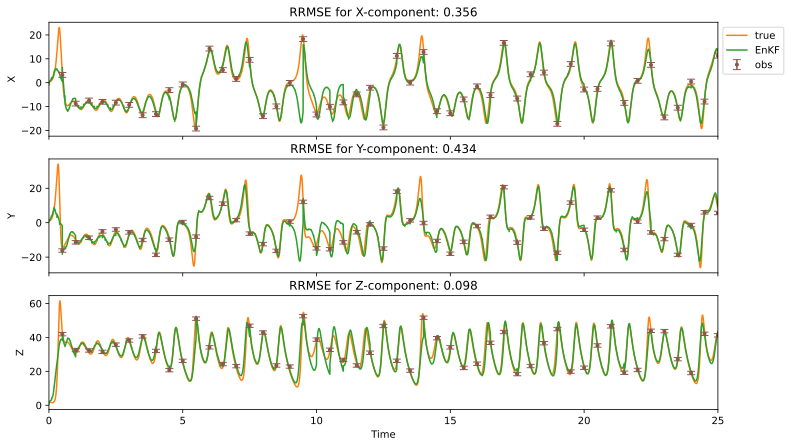

In [44]:
# Plot results
# cum_error_comp = torch.mean((xt - xEnKF) ** 2, dim=1)
cum_error_comp = torch.sum((xt - xEnKF) ** 2, dim=1)
norm_comp = torch.sum(xt**2, dim=1)
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    ax[k].plot(time.cpu(), xEnKF.cpu()[k, :], color="#2ca02c", label='EnKF')
    # ax[k].plot(time.cpu(), x_estimates.cpu()[k, :], label='EnKF')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        iobs += 1
    # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}%"
        f"RRMSE for {comp}-component: {torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}"
    )
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Background state assimilation with 4DVar

In [45]:
start_time_point, end_time_point = 17, 20
gaps = [gap] * (y.T[start_time_point:end_time_point].size(0) - 1)
lstm_model = lstm_model.train()

parameters = torchda.Parameters(
    algorithm=torchda.Algorithms.Var4D,
    device=torchda.Device.GPU,
    observation_time_steps=time_obs[start_time_point:end_time_point],
    gaps=gaps,
    observation_model=H,
    output_sequence_length=lstm_model.out_seq_length,
    forward_model=lstm_model,
    background_covariance_matrix=P0,
    observation_covariance_matrix=R,
    background_state=y.T[start_time_point],
    observations=y.T,
    optimizer_cls=torch.optim.Adam,
    optimizer_args={"lr": 0.5},
    max_iterations=200
)

run_case = torchda.CaseBuilder().set_parameters(parameters)

if parameters.device is torchda.Device.GPU:

    def H(x: torch.Tensor):
        h = torch.zeros((y_size, 3), device="cuda")
        iy = 0
        for ix in range(3):
            if WhichVariablesAreObserved[ix] > 0:
                h[iy, ix] = 1.
                iy += 1
        return x @ h.T

    run_case.set_observation_model(H)

var4d_res = "4dvar.case_two.data"
if not os.path.exists(var4d_res):
    results = run_case.execute()
    x0 = results["assimilated_state"]
    torch.save(x0, var4d_res)
else:
    x0 = torch.load(var4d_res, map_location="cpu")

Timestamp: 2024-07-23 00:04:13.094396, Iterations: 0, Jb: 0.0, Jo: 3005.49365234375, J: 3005.49365234375, Norm of J gradient: 503.88555908203125
Timestamp: 2024-07-23 00:04:15.445973, Iterations: 1, Jb: 0.7499998807907104, Jo: 1946.7064208984375, J: 1947.4564208984375, Norm of J gradient: 1144.561279296875
Timestamp: 2024-07-23 00:04:17.800259, Iterations: 2, Jb: 2.175351142883301, Jo: 1444.4400634765625, J: 1446.6153564453125, Norm of J gradient: 363.8552551269531
Timestamp: 2024-07-23 00:04:20.159735, Iterations: 3, Jb: 4.177133083343506, Jo: 1301.568115234375, J: 1305.7452392578125, Norm of J gradient: 121.79765319824219
Timestamp: 2024-07-23 00:04:22.349032, Iterations: 4, Jb: 6.576364040374756, Jo: 1266.322021484375, J: 1272.8984375, Norm of J gradient: 35.234336853027344
Timestamp: 2024-07-23 00:04:24.718809, Iterations: 5, Jb: 9.157362937927246, Jo: 1273.1693115234375, J: 1282.32666015625, Norm of J gradient: 40.36722946166992
Timestamp: 2024-07-23 00:04:27.032763, Iterations: 6

In [46]:
x0 = x0.to(device)
lstm_model = lstm_model.to(device)
outs = [xb.view(1, -1) if (xb:=x0).ndim == 1 else x0]
x = outs[0]
start_end_time = time_obs[start_time_point:end_time_point]
for i in range(1, len(start_end_time)):
    time_fw = torch.linspace(start_end_time[i-1], start_end_time[i], gap+1)
    forward_times, residue = divmod(len(time_fw[:-1]), lstm_model.out_seq_length)
    for _ in range(forward_times+1):
        x = lstm_model(x)
        outs.append(x)
        x = x[-1]
    outs[-1] = outs[-1][:residue]
outs = torch.cat(outs).T

In [47]:
time_idxs = [
    i
    for i, t in enumerate(time)
    if t in time_obs[start_time_point:end_time_point]
]
var4d_times = time[time_idxs[0]:time_idxs[-1]+1]

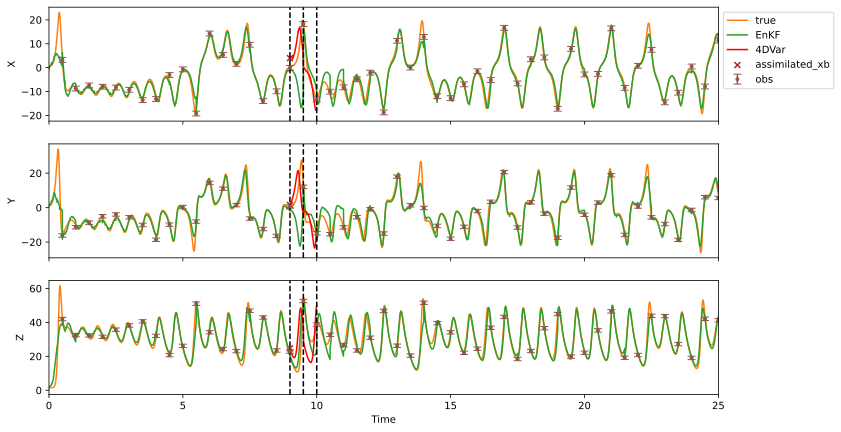

In [48]:
# Plot results
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    # ax[k].plot(time.cpu(), lstm_outs.detach().numpy()[k, :], color="#1f77b4", label='lstm')
    ax[k].plot(time.cpu(), xEnKF.cpu()[k, :], color="#2ca02c", label='EnKF')
    ax[k].plot(var4d_times.cpu(), outs.detach().numpy()[k, :], color="red", label='4DVar')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        ax[k].scatter(time_obs[start_time_point].cpu(), x0.cpu()[k],
                      color="brown", marker="x", label='assimilated_xb')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    for x in time_obs[start_time_point:end_time_point]:
        ax[k].axvline(x, color="k", linestyle="--")
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

In [49]:
noda_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - lstm_outs.detach().numpy()[:, time_idxs[0]:time_idxs[-1]+1]) ** 2)
enkf_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2)
var4d_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2)
norm = torch.sum(xt[:, time_idxs[0]:time_idxs[-1]+1]**2)
print("Relative errors (RRMSE) in %")
print(f"3-component: {100.0 * torch.sqrt(noda_cum_error / norm):.1f} (No DA)")
print(f"3-component: {100.0 * torch.sqrt(enkf_cum_error / norm):.1f} (EnKF)")
print(f"3-component: {100.0 * torch.sqrt(var4d_cum_error / norm):.1f} (4DVar)\n")
print("Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - lstm_outs.detach().numpy()[:, time_idxs[0]:time_idxs[-1]+1]) ** 2):.1f} (No DA)")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2):.1f} (EnKF)")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2):.1f} (4DVar)")

Relative errors (RRMSE) in %
3-component: 79.0 (No DA)
3-component: 68.4 (EnKF)
3-component: 57.5 (4DVar)

Relative errors (MSE) in %
3-component: 24146.6 (No DA)
3-component: 18117.1 (EnKF)
3-component: 12814.0 (4DVar)


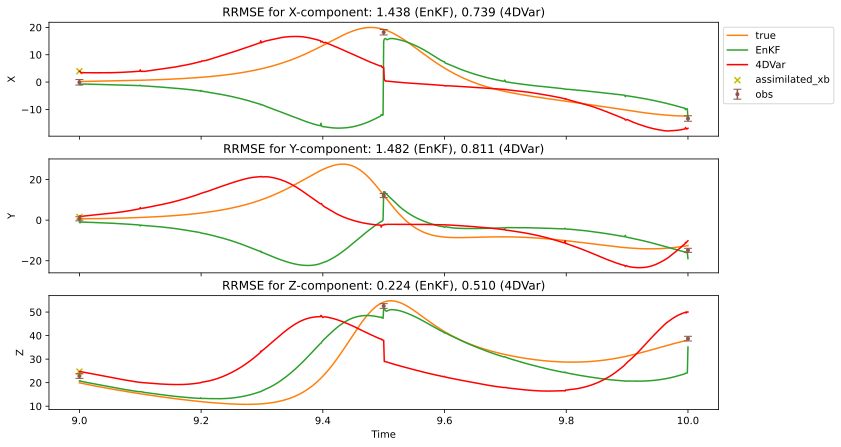

In [50]:
# Plot results
enkf_cum_error_comp = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2, dim=1)
# enkf_cum_error_comp = torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2, dim=1)
var4d_cum_error_comp = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2, dim=1)
# var4d_cum_error_comp = torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2, dim=1)
norm_comp = torch.sum(xt[:, time_idxs[0]:time_idxs[-1]+1]**2, dim=1)
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(var4d_times.cpu(), xt.cpu()[k, time_idxs[0]:time_idxs[-1]+1], color="#ff7f0e", label='true')
    # ax[k].plot(var4d_times.cpu(), lstm_outs.detach().numpy()[k, time_idxs[0]:time_idxs[-1]+1], color="#1f77b4", label='lstm')
    ax[k].plot(var4d_times.cpu(), xEnKF.cpu()[k, time_idxs[0]:time_idxs[-1]+1], color="#2ca02c", label='EnKF')
    ax[k].plot(var4d_times.cpu(), outs.detach().numpy()[k, :], color="red", label='4DVar')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu()[start_time_point:end_time_point], y.cpu()[iobs, start_time_point:end_time_point],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        ax[k].scatter(time_obs[start_time_point].cpu(), x0.cpu()[k],
                      color="y", marker="x", label='assimilated_xb')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(enkf_cum_error_comp[k] / norm_comp[k]):.3f}% (EnKF), {100 * torch.sqrt(var4d_cum_error_comp[k] / norm_comp[k]):.3f}% (4DVar)"
        f"RRMSE for {comp}-component: {torch.sqrt(enkf_cum_error_comp[k] / norm_comp[k]):.3f} (EnKF), {torch.sqrt(var4d_cum_error_comp[k] / norm_comp[k]):.3f} (4DVar)"
    )
ax[-1].set_xlabel('Time')
# ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

### 3) `sigobs = 2.0 * sigens`

In [51]:
torch.cuda.empty_cache()

# Construct observations in a time window

In [52]:
# We define the control parameters here
rayleigh = 35
prandtl = 10.
b = 8./3.
# initial condition for the true reference trajectory
x0 = torch.tensor([0., 1., 2.], device=device)

# integration time parameter
dt = 1.e-3      # This is time step size
T = 25.         # Total integration time, can be as short as 10 to speed things up
num_steps = ceil(T / dt)
time = torch.linspace(0., T, num_steps + 1, device=device)  # array of discrete times

# numerical integration given initial conditions and control parameters
xt = forwardModel_r(x0, time, rayleigh, prandtl, b)

In [53]:
# Which variables do we observe?
WhichVariablesAreObserved = torch.tensor([1, 1, 1])
#  Determines which variables are available to
#  the EnKF. For example:
#  WhichVariablesAreObserved = [1 1 1];
#  means: X, Y, Z are observed
#  WhichVariablesAreObserved = [1 0 1];
#  means: X and Z are observed
#  WhichVariablesAreObserved = [1 0 0];
# means: X is observed
# We generate the synthetic data
#  Construct observation matrix H
#  ........................................................................
y_size = int(WhichVariablesAreObserved.sum())
# Callable H
def H(x: torch.Tensor):
    h = torch.zeros((y_size, 3), device=device)
    iy = 0
    for ix in range(3):
        if WhichVariablesAreObserved[ix] > 0:
            h[iy, ix] = 1.
            iy += 1
    return h @ x
# # Tensor H
# H = torch.zeros((y_size, 3), device=device)
# iy = 0
# for ix in range(3):
#     if WhichVariablesAreObserved[ix] > 0:
#         H[iy, ix] = 1.
#         iy += 1

In [54]:
# How often do we observe the true state?
dtobs = 0.5  # time between observations
# no observation at t=0
gap = int(dtobs / dt)  # number of time steps between each observation
time_obs = time[gap::gap]
# Generate vector of observations
sigobs = 2.0  # standard deviation of the observation noise
R = (sigobs**2) * torch.eye(y_size, device=device)
sqrt_s = torch.sqrt(R)
# y = Hxt
y = H @ xt[:, gap::gap] if isinstance(H, torch.Tensor) else H(xt[:, gap::gap])
# compute observation error
noise = sqrt_s @ torch.randn(size=y.shape, device=device)
# y = Hxt + epsilon
y = y + noise

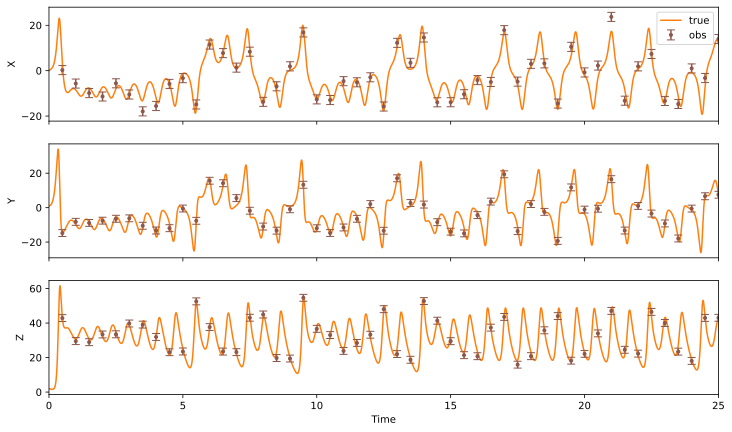

In [55]:
# Plot reference trajectory and the observations that will be fed to the EnKF
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
# fig.suptitle('Reference trajectory + observations')
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Forward prediction test without EnKF

In [56]:
lstm_model = lstm_model.to(device)
lstm_model.eval()

LSTM_1TON(
  (fc_in): Linear(in_features=3, out_features=12, bias=True)
  (lstm): LSTM(3, 12, num_layers=20, batch_first=True)
  (fc): Linear(in_features=12, out_features=3, bias=True)
)

In [57]:
xtT = xt.T
print(f"{xtT.shape=}")
lstm_outs = [xtT0.view(1, -1) if (xtT0:=xtT[0]).ndim == 1 else xtT0]
next_in = lstm_outs[0]
with torch.no_grad():
    forward_times, residue = divmod(xtT.size(0)-1, lstm_model.out_seq_length)
    for _ in range(forward_times+1):
        outs = lstm_model(next_in)
        lstm_outs.append(outs)
        next_in = outs[-1]
    lstm_outs[-1] = lstm_outs[-1][:residue]
    lstm_outs = torch.cat(lstm_outs).T
lstm_outs.shape

xtT.shape=torch.Size([25001, 3])


torch.Size([3, 25001])

In [58]:
# Compute Euclidean error wrt true state which is known in this synthetic game
# cumulative error
cum_error_comp = torch.sum((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
cum_error = torch.sum(cum_error_comp)
norm_comp = torch.sum(xt**2, dim=1)
norm = torch.sum(xt**2)
print("No DA Relative errors (RRMSE) in %")
for k, comp in enumerate(["X", "Y", "Z"]):
    print(f"{comp}-component: {100.0 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.1f}")
print(f"3-component: {100.0 * torch.sqrt(cum_error / norm):.1f}\n")
print("No DA Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt - lstm_outs.detach().numpy()) ** 2):.1f}")

No DA Relative errors (RRMSE) in %
X-component: 125.7
Y-component: 123.4
Z-component: 40.3
3-component: 61.8

No DA Relative errors (MSE) in %
3-component: 15831.1


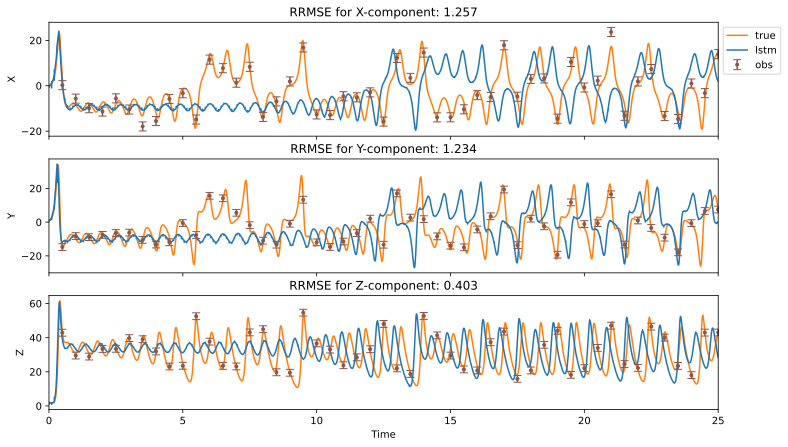

In [59]:
# cum_error_comp = torch.mean((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
cum_error_comp = torch.sum((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
norm_comp = torch.sum(xt**2, dim=1)
# Plot reference trajectory and the observations that will be fed to the EnKF
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    ax[k].plot(time.cpu(), lstm_outs.detach().numpy()[k, :], color="#1f77b4", label='lstm')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}%"
        f"RRMSE for {comp}-component: {torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}"
    )
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Forward prediction test with EnKF

In [60]:
# Initialization of the Ensemble
Ne = 50  # Number of ensemble members
sigens = 1.  # standard deviation of the ensemble
# initial covariance matrix
P0 = (sigens**2)*torch.eye(3, device=device)

## Recall that we generated a vector of observations before
```python
sigobs = 2.0  # standard deviation of the observation noise
R = (sigobs**2) * torch.eye(y_size, device=device)
sqrt_s = torch.sqrt(R)
# y = Hxt
y = H @ xt[:, gap::gap] if isinstance(H, torch.Tensor) else H(xt[:, gap::gap])
# compute observation error
noise = sqrt_s @ torch.randn(size=y.shape, device=device)
# y = Hxt + epsilon
y = y + noise
```

In [61]:
# Callable H
def H(x: torch.Tensor):
    h = torch.zeros((y_size, 3), device=device) 
    iy = 0
    for ix in range(3):
        if WhichVariablesAreObserved[ix] > 0:
            h[iy, ix] = 1.
            iy += 1
    return x @ h.T
# H = torch.randn((y_size, 3), device=device)
# # Tensor H
# H = torch.zeros((y_size, 3), device=device)
# iy = 0
# for ix in range(3):
#     if WhichVariablesAreObserved[ix] > 0:
#         H[iy, ix] = 1.
#         iy += 1

In [62]:
# Now we run the EnKF
gaps = [gap] * len(time_obs)
# xEnKF, x_ens = apply_EnKF(
#     time_obs, gaps, Ne, M, H, P0, R, xtT[0], y.T
# )
# xEnKF, x_ens = xEnKF.T, x_ens.transpose(0, -1)

In [63]:
import torchda

parameters = torchda.Parameters(
    algorithm=torchda.Algorithms.EnKF,
    device=torchda.Device.CPU,
    observation_time_steps=time_obs,
    gaps=gaps,
    num_ensembles=Ne,
    observation_model=H,
    output_sequence_length=lstm_model.out_seq_length,
    forward_model=lstm_model,
    background_covariance_matrix=P0,
    observation_covariance_matrix=R,
    background_state=xtT[0],
    observations=y.T,
)

run_case = torchda.CaseBuilder(parameters=parameters)

if parameters.device is torchda.Device.GPU:

    def H(x: torch.Tensor):
        h = torch.zeros((y_size, 3), device="cuda")
        iy = 0
        for ix in range(3):
            if WhichVariablesAreObserved[ix] > 0:
                h[iy, ix] = 1.
                iy += 1
        return x @ h.T

    run_case.set_observation_model(H)

enkf_res = "xEnKF_100ep.case_three.data"
all_enkf_res = "x_ens_100ep.case_three.data"
if not (os.path.exists(enkf_res) and os.path.exists(all_enkf_res)):
    results = run_case.execute()
    xEnKF, x_ens = results["average_ensemble_all_states"].T.to("cpu"), results["each_ensemble_all_states"].transpose(0, -1).to("cpu")
    torch.save(xEnKF, enkf_res)
    torch.save(x_ens, all_enkf_res)
else:
    xEnKF = torch.load(enkf_res, map_location="cpu")
    x_ens = torch.load(all_enkf_res, map_location="cpu")

In [64]:
# Compute Euclidean error wrt true state which is known in this synthetic game
# cumulative error
# cum_error_comp = torch.sqrt(torch.sum((xt - x_estimates) ** 2, dim=1))
cum_error_comp = torch.sum((xt - xEnKF) ** 2, dim=1)
cum_error = torch.sum(cum_error_comp)
norm_comp = torch.sum(xt**2, dim=1)
norm = torch.sum(xt**2)
print("EnKF Relative errors (RRMSE) in %")
for k, comp in enumerate(["X", "Y", "Z"]):
    print(f"{comp}-component: {100.0 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.1f}")
print(f"3-component: {100.0 * torch.sqrt(cum_error / norm):.1f}\n")
print("EnKF Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt - xEnKF) ** 2):.1f}")

EnKF Relative errors (RRMSE) in %
X-component: 43.7
Y-component: 52.7
Z-component: 13.6
3-component: 23.1

EnKF Relative errors (MSE) in %
3-component: 2222.7


In [65]:
all_3component_error = []
for e in range(Ne):
    cum_error_comp_one = torch.sum((xt - x_ens[:, e]) ** 2, dim=1)
    cum_error_one = torch.sum(cum_error_comp_one)
    all_3component_error.append(float(100.0 * torch.sqrt(cum_error_one / norm)))
print(f"max error in all components: {max(all_3component_error)}%")

max error in all components: 37.93796157836914%


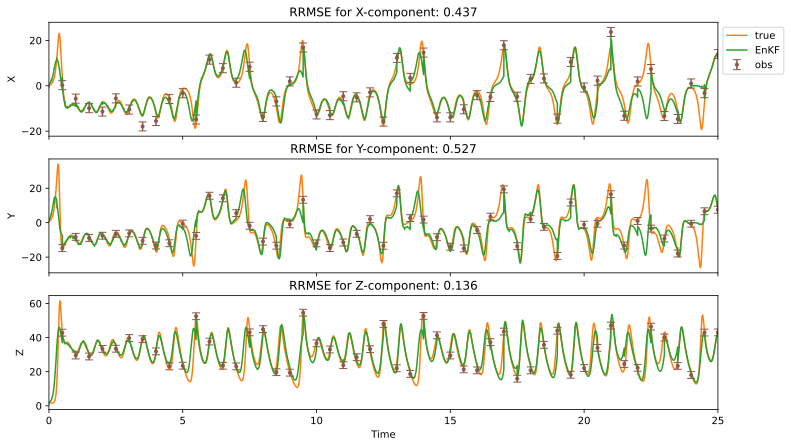

In [66]:
# Plot results
# cum_error_comp = torch.mean((xt - xEnKF) ** 2, dim=1)
cum_error_comp = torch.sum((xt - xEnKF) ** 2, dim=1)
norm_comp = torch.sum(xt**2, dim=1)
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    ax[k].plot(time.cpu(), xEnKF.cpu()[k, :], color="#2ca02c", label='EnKF')
    # ax[k].plot(time.cpu(), x_estimates.cpu()[k, :], label='EnKF')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        iobs += 1
    # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}%"
        f"RRMSE for {comp}-component: {torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}"
    )
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Background state assimilation with 4DVar

In [67]:
start_time_point, end_time_point = 17, 20
gaps = [gap] * (y.T[start_time_point:end_time_point].size(0) - 1)
lstm_model = lstm_model.train()

parameters = torchda.Parameters(
    algorithm=torchda.Algorithms.Var4D,
    device=torchda.Device.GPU,
    observation_time_steps=time_obs[start_time_point:end_time_point],
    gaps=gaps,
    observation_model=H,
    output_sequence_length=lstm_model.out_seq_length,
    forward_model=lstm_model,
    background_covariance_matrix=P0,
    observation_covariance_matrix=R,
    background_state=y.T[start_time_point],
    observations=y.T,
    optimizer_cls=torch.optim.Adam,
    optimizer_args={"lr": 0.5},
    max_iterations=200
)

run_case = torchda.CaseBuilder().set_parameters(parameters)

if parameters.device is torchda.Device.GPU:

    def H(x: torch.Tensor):
        h = torch.zeros((y_size, 3), device="cuda")
        iy = 0
        for ix in range(3):
            if WhichVariablesAreObserved[ix] > 0:
                h[iy, ix] = 1.
                iy += 1
        return x @ h.T

    run_case.set_observation_model(H)

var4d_res = "4dvar.case_three.data"
if not os.path.exists(var4d_res):
    results = run_case.execute()
    x0 = results["assimilated_state"]
    torch.save(x0, var4d_res)
else:
    x0 = torch.load(var4d_res, map_location="cpu")

Timestamp: 2024-07-23 00:32:11.432743, Iterations: 0, Jb: 0.0, Jo: 642.4620971679688, J: 642.4620971679688, Norm of J gradient: 1056.69384765625
Timestamp: 2024-07-23 00:32:13.681653, Iterations: 1, Jb: 0.7499999403953552, Jo: 636.4735107421875, J: 637.2235107421875, Norm of J gradient: 99.06094360351562
Timestamp: 2024-07-23 00:32:16.427384, Iterations: 2, Jb: 2.2028229236602783, Jo: 597.761962890625, J: 599.9647827148438, Norm of J gradient: 156.91116333007812
Timestamp: 2024-07-23 00:32:18.622176, Iterations: 3, Jb: 4.254316329956055, Jo: 530.3885498046875, J: 534.6428833007812, Norm of J gradient: 7.748281002044678
Timestamp: 2024-07-23 00:32:21.205986, Iterations: 4, Jb: 6.343355178833008, Jo: 497.4000244140625, J: 503.7433776855469, Norm of J gradient: 73.406494140625
Timestamp: 2024-07-23 00:32:23.417155, Iterations: 5, Jb: 8.692022323608398, Jo: 479.2832336425781, J: 487.9752502441406, Norm of J gradient: 38.47842788696289
Timestamp: 2024-07-23 00:32:25.680707, Iterations: 6, J

In [68]:
x0 = x0.to(device)
lstm_model = lstm_model.to(device)
outs = [xb.view(1, -1) if (xb:=x0).ndim == 1 else x0]
x = outs[0]
start_end_time = time_obs[start_time_point:end_time_point]
for i in range(1, len(start_end_time)):
    time_fw = torch.linspace(start_end_time[i-1], start_end_time[i], gap+1)
    forward_times, residue = divmod(len(time_fw[:-1]), lstm_model.out_seq_length)
    for _ in range(forward_times+1):
        x = lstm_model(x)
        outs.append(x)
        x = x[-1]
    outs[-1] = outs[-1][:residue]
outs = torch.cat(outs).T

In [69]:
time_idxs = [
    i
    for i, t in enumerate(time)
    if t in time_obs[start_time_point:end_time_point]
]
var4d_times = time[time_idxs[0]:time_idxs[-1]+1]

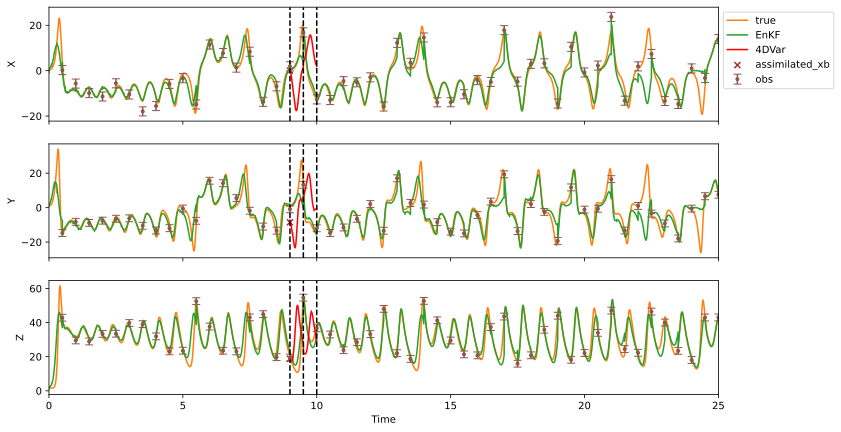

In [70]:
# Plot results
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    # ax[k].plot(time.cpu(), lstm_outs.detach().numpy()[k, :], color="#1f77b4", label='lstm')
    ax[k].plot(time.cpu(), xEnKF.cpu()[k, :], color="#2ca02c", label='EnKF')
    ax[k].plot(var4d_times.cpu(), outs.detach().numpy()[k, :], color="red", label='4DVar')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        ax[k].scatter(time_obs[start_time_point].cpu(), x0.cpu()[k],
                      color="brown", marker="x", label='assimilated_xb')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    for x in time_obs[start_time_point:end_time_point]:
        ax[k].axvline(x, color="k", linestyle="--")
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

In [71]:
noda_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - lstm_outs.detach().numpy()[:, time_idxs[0]:time_idxs[-1]+1]) ** 2)
enkf_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2)
var4d_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2)
norm = torch.sum(xt[:, time_idxs[0]:time_idxs[-1]+1]**2)
print("Relative errors (RRMSE) in %")
print(f"3-component: {100.0 * torch.sqrt(noda_cum_error / norm):.1f} (No DA)")
print(f"3-component: {100.0 * torch.sqrt(enkf_cum_error / norm):.1f} (EnKF)")
print(f"3-component: {100.0 * torch.sqrt(var4d_cum_error / norm):.1f} (4DVar)\n")
print("Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - lstm_outs.detach().numpy()[:, time_idxs[0]:time_idxs[-1]+1]) ** 2):.1f} (No DA)")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2):.1f} (EnKF)")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2):.1f} (4DVar)")

Relative errors (RRMSE) in %
3-component: 79.0 (No DA)
3-component: 30.1 (EnKF)
3-component: 91.7 (4DVar)

Relative errors (MSE) in %
3-component: 24146.6 (No DA)
3-component: 3519.1 (EnKF)
3-component: 32558.8 (4DVar)


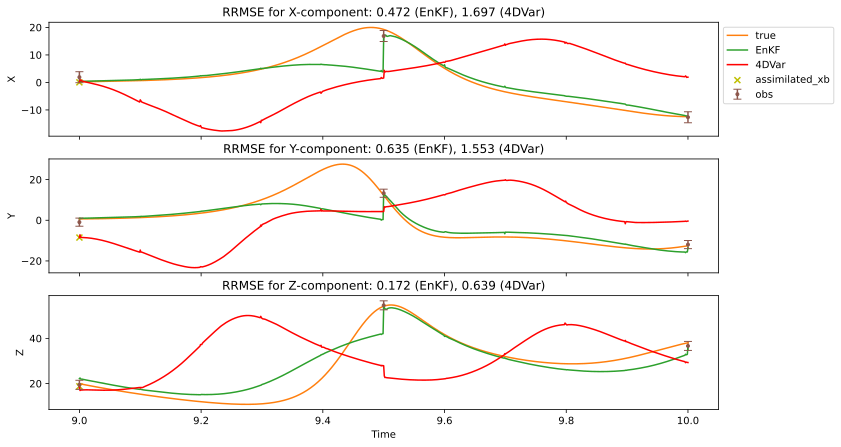

In [72]:
# Plot results
enkf_cum_error_comp = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2, dim=1)
# enkf_cum_error_comp = torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2, dim=1)
var4d_cum_error_comp = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2, dim=1)
# var4d_cum_error_comp = torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2, dim=1)
norm_comp = torch.sum(xt[:, time_idxs[0]:time_idxs[-1]+1]**2, dim=1)
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(var4d_times.cpu(), xt.cpu()[k, time_idxs[0]:time_idxs[-1]+1], color="#ff7f0e", label='true')
    # ax[k].plot(var4d_times.cpu(), lstm_outs.detach().numpy()[k, time_idxs[0]:time_idxs[-1]+1], color="#1f77b4", label='lstm')
    ax[k].plot(var4d_times.cpu(), xEnKF.cpu()[k, time_idxs[0]:time_idxs[-1]+1], color="#2ca02c", label='EnKF')
    ax[k].plot(var4d_times.cpu(), outs.detach().numpy()[k, :], color="red", label='4DVar')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu()[start_time_point:end_time_point], y.cpu()[iobs, start_time_point:end_time_point],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        ax[k].scatter(time_obs[start_time_point].cpu(), x0.cpu()[k],
                      color="y", marker="x", label='assimilated_xb')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(enkf_cum_error_comp[k] / norm_comp[k]):.3f}% (EnKF), {100 * torch.sqrt(var4d_cum_error_comp[k] / norm_comp[k]):.3f}% (4DVar)"
        f"RRMSE for {comp}-component: {torch.sqrt(enkf_cum_error_comp[k] / norm_comp[k]):.3f} (EnKF), {torch.sqrt(var4d_cum_error_comp[k] / norm_comp[k]):.3f} (4DVar)"
    )
ax[-1].set_xlabel('Time')
# ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

### 4) `sigobs = 1e-3` and `R` is an identity matrix

In [73]:
torch.cuda.empty_cache()

# Construct observations in a time window

In [74]:
# We define the control parameters here
rayleigh = 35
prandtl = 10.
b = 8./3.
# initial condition for the true reference trajectory
x0 = torch.tensor([0., 1., 2.], device=device)

# integration time parameter
dt = 1.e-3      # This is time step size
T = 25.         # Total integration time, can be as short as 10 to speed things up
num_steps = ceil(T / dt)
time = torch.linspace(0., T, num_steps + 1, device=device)  # array of discrete times

# numerical integration given initial conditions and control parameters
xt = forwardModel_r(x0, time, rayleigh, prandtl, b)

In [75]:
# Which variables do we observe?
WhichVariablesAreObserved = torch.tensor([1, 1, 1])
#  Determines which variables are available to
#  the EnKF. For example:
#  WhichVariablesAreObserved = [1 1 1];
#  means: X, Y, Z are observed
#  WhichVariablesAreObserved = [1 0 1];
#  means: X and Z are observed
#  WhichVariablesAreObserved = [1 0 0];
# means: X is observed
# We generate the synthetic data
#  Construct observation matrix H
#  ........................................................................
y_size = int(WhichVariablesAreObserved.sum())
# Callable H
def H(x: torch.Tensor):
    h = torch.zeros((y_size, 3), device=device)
    iy = 0
    for ix in range(3):
        if WhichVariablesAreObserved[ix] > 0:
            h[iy, ix] = 1.
            iy += 1
    return h @ x
# # Tensor H
# H = torch.zeros((y_size, 3), device=device)
# iy = 0
# for ix in range(3):
#     if WhichVariablesAreObserved[ix] > 0:
#         H[iy, ix] = 1.
#         iy += 1

In [76]:
# How often do we observe the true state?
dtobs = 0.5  # time between observations
# no observation at t=0
gap = int(dtobs / dt)  # number of time steps between each observation
time_obs = time[gap::gap]
# Generate vector of observations
sigobs = 1e-3  # standard deviation of the observation noise
sqrt_s = torch.sqrt((sigobs**2) * torch.eye(y_size, device=device))
# y = Hxt
y = H @ xt[:, gap::gap] if isinstance(H, torch.Tensor) else H(xt[:, gap::gap])
# compute observation error
noise = sqrt_s @ torch.randn(size=y.shape, device=device)
# y = Hxt + epsilon
y = y + noise

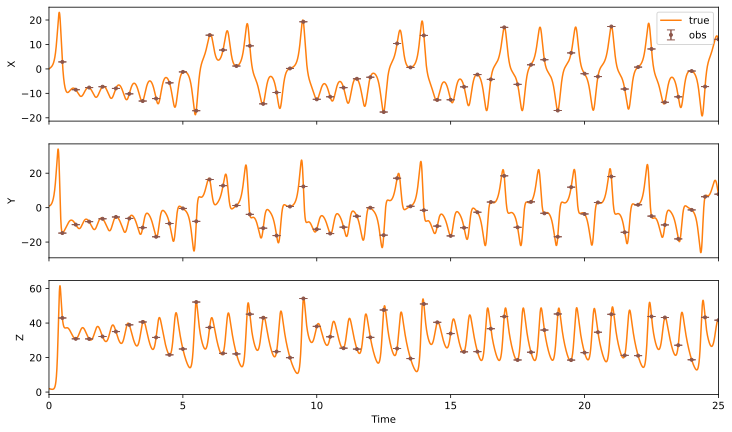

In [77]:
# Plot reference trajectory and the observations that will be fed to the EnKF
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
# fig.suptitle('Reference trajectory + observations')
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Forward prediction test without EnKF

In [78]:
lstm_model = lstm_model.to(device)
lstm_model.eval()

LSTM_1TON(
  (fc_in): Linear(in_features=3, out_features=12, bias=True)
  (lstm): LSTM(3, 12, num_layers=20, batch_first=True)
  (fc): Linear(in_features=12, out_features=3, bias=True)
)

In [79]:
xtT = xt.T
print(f"{xtT.shape=}")
lstm_outs = [xtT0.view(1, -1) if (xtT0:=xtT[0]).ndim == 1 else xtT0]
next_in = lstm_outs[0]
with torch.no_grad():
    forward_times, residue = divmod(xtT.size(0)-1, lstm_model.out_seq_length)
    for _ in range(forward_times+1):
        outs = lstm_model(next_in)
        lstm_outs.append(outs)
        next_in = outs[-1]
    lstm_outs[-1] = lstm_outs[-1][:residue]
    lstm_outs = torch.cat(lstm_outs).T
lstm_outs.shape

xtT.shape=torch.Size([25001, 3])


torch.Size([3, 25001])

In [80]:
# Compute Euclidean error wrt true state which is known in this synthetic game
# cumulative error
cum_error_comp = torch.sum((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
cum_error = torch.sum(cum_error_comp)
norm_comp = torch.sum(xt**2, dim=1)
norm = torch.sum(xt**2)
print("No DA Relative errors (RRMSE) in %")
for k, comp in enumerate(["X", "Y", "Z"]):
    print(f"{comp}-component: {100.0 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.1f}")
print(f"3-component: {100.0 * torch.sqrt(cum_error / norm):.1f}\n")
print("No DA Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt - lstm_outs.detach().numpy()) ** 2):.1f}")

No DA Relative errors (RRMSE) in %
X-component: 125.7
Y-component: 123.4
Z-component: 40.3
3-component: 61.8

No DA Relative errors (MSE) in %
3-component: 15831.1


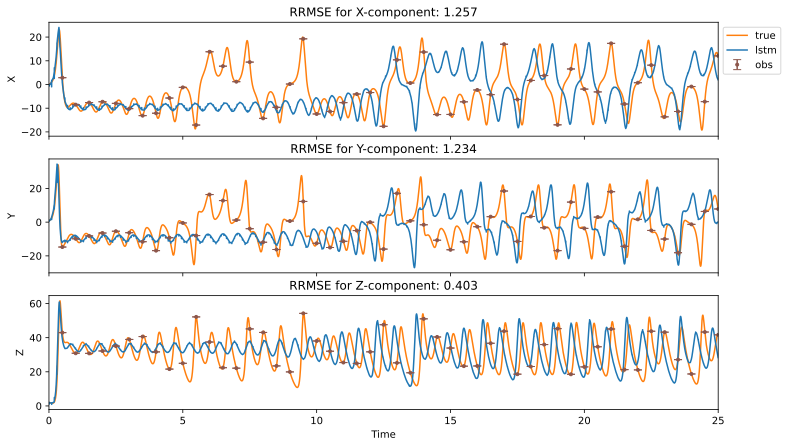

In [81]:
# cum_error_comp = torch.mean((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
cum_error_comp = torch.sum((xt - lstm_outs.detach().numpy()) ** 2, dim=1)
norm_comp = torch.sum(xt**2, dim=1)
# Plot reference trajectory and the observations that will be fed to the EnKF
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    ax[k].plot(time.cpu(), lstm_outs.detach().numpy()[k, :], color="#1f77b4", label='lstm')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}%"
        f"RRMSE for {comp}-component: {torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}"
    )
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Forward prediction test with EnKF

In [82]:
# Initialization of the Ensemble
Ne = 50  # Number of ensemble members
sigens = 1.  # standard deviation of the ensemble
# initial covariance matrix
P0 = (sigens**2)*torch.eye(3, device=device)

### This case `sigobs = 1e-3` and `R` is an identity matrix

In [83]:
# Callable H
def H(x: torch.Tensor):
    h = torch.zeros((y_size, 3), device=device) 
    iy = 0
    for ix in range(3):
        if WhichVariablesAreObserved[ix] > 0:
            h[iy, ix] = 1.
            iy += 1
    return x @ h.T
# H = torch.randn((y_size, 3), device=device)
# # Tensor H
# H = torch.zeros((y_size, 3), device=device)
# iy = 0
# for ix in range(3):
#     if WhichVariablesAreObserved[ix] > 0:
#         H[iy, ix] = 1.
#         iy += 1

In [84]:
# Now we run the EnKF
gaps = [gap] * len(time_obs)
# xEnKF, x_ens = apply_EnKF(
#     time_obs, gaps, Ne, M, H, P0, R, xtT[0], y.T
# )
# xEnKF, x_ens = xEnKF.T, x_ens.transpose(0, -1)

In [85]:
import torchda

parameters = torchda.Parameters(
    algorithm=torchda.Algorithms.EnKF,
    device=torchda.Device.CPU,
    observation_time_steps=time_obs,
    gaps=gaps,
    num_ensembles=Ne,
    observation_model=H,
    output_sequence_length=lstm_model.out_seq_length,
    forward_model=lstm_model,
    background_covariance_matrix=P0,
    observation_covariance_matrix=torch.eye(y_size, device=device),
    background_state=xtT[0],
    observations=y.T,
)

run_case = torchda.CaseBuilder(parameters=parameters)

if parameters.device is torchda.Device.GPU:

    def H(x: torch.Tensor):
        h = torch.zeros((y_size, 3), device="cuda")
        iy = 0
        for ix in range(3):
            if WhichVariablesAreObserved[ix] > 0:
                h[iy, ix] = 1.
                iy += 1
        return x @ h.T

    run_case.set_observation_model(H)

enkf_res = "xEnKF_100ep.case_four.data"
all_enkf_res = "x_ens_100ep.case_four.data"
if not (os.path.exists(enkf_res) and os.path.exists(all_enkf_res)):
    results = run_case.execute()
    xEnKF, x_ens = results["average_ensemble_all_states"].T.to("cpu"), results["each_ensemble_all_states"].transpose(0, -1).to("cpu")
    torch.save(xEnKF, enkf_res)
    torch.save(x_ens, all_enkf_res)
else:
    xEnKF = torch.load(enkf_res, map_location="cpu")
    x_ens = torch.load(all_enkf_res, map_location="cpu")

In [86]:
# Compute Euclidean error wrt true state which is known in this synthetic game
# cumulative error
# cum_error_comp = torch.sqrt(torch.sum((xt - x_estimates) ** 2, dim=1))
cum_error_comp = torch.sum((xt - xEnKF) ** 2, dim=1)
cum_error = torch.sum(cum_error_comp)
norm_comp = torch.sum(xt**2, dim=1)
norm = torch.sum(xt**2)
print("EnKF Relative errors (RRMSE) in %")
for k, comp in enumerate(["X", "Y", "Z"]):
    print(f"{comp}-component: {100.0 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.1f}")
print(f"3-component: {100.0 * torch.sqrt(cum_error / norm):.1f}\n")
print("EnKF Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt - xEnKF) ** 2):.1f}")

EnKF Relative errors (RRMSE) in %
X-component: 21.6
Y-component: 28.2
Z-component: 8.7
3-component: 12.9

EnKF Relative errors (MSE) in %
3-component: 694.4


In [87]:
all_3component_error = []
for e in range(Ne):
    cum_error_comp_one = torch.sum((xt - x_ens[:, e]) ** 2, dim=1)
    cum_error_one = torch.sum(cum_error_comp_one)
    all_3component_error.append(float(100.0 * torch.sqrt(cum_error_one / norm)))
print(f"max error in all components: {max(all_3component_error)}%")

max error in all components: 24.482065200805664%


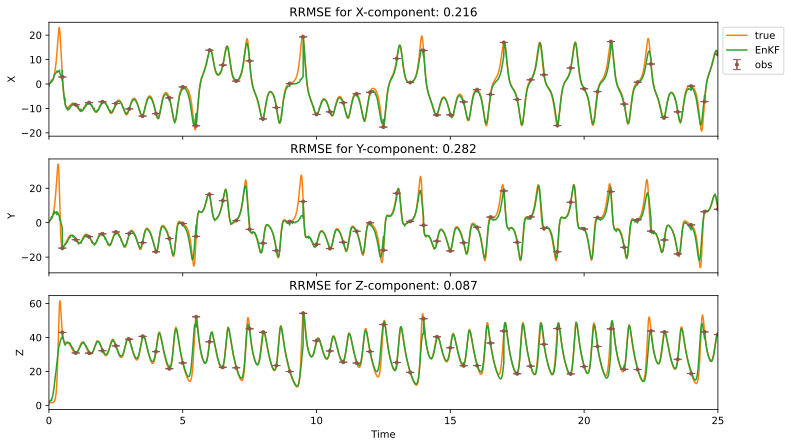

In [88]:
# Plot results
# cum_error_comp = torch.mean((xt - xEnKF) ** 2, dim=1)
cum_error_comp = torch.sum((xt - xEnKF) ** 2, dim=1)
norm_comp = torch.sum(xt**2, dim=1)
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    ax[k].plot(time.cpu(), xEnKF.cpu()[k, :], color="#2ca02c", label='EnKF')
    # ax[k].plot(time.cpu(), x_estimates.cpu()[k, :], label='EnKF')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        iobs += 1
    # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}%"
        f"RRMSE for {comp}-component: {torch.sqrt(cum_error_comp[k] / norm_comp[k]):.3f}"
    )
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

# Background state assimilation with 4DVar

In [89]:
start_time_point, end_time_point = 17, 20
gaps = [gap] * (y.T[start_time_point:end_time_point].size(0) - 1)
lstm_model = lstm_model.train()

parameters = torchda.Parameters(
    algorithm=torchda.Algorithms.Var4D,
    device=torchda.Device.GPU,
    observation_time_steps=time_obs[start_time_point:end_time_point],
    gaps=gaps,
    observation_model=H,
    output_sequence_length=lstm_model.out_seq_length,
    forward_model=lstm_model,
    background_covariance_matrix=P0,
    observation_covariance_matrix=torch.eye(y_size, device=device),
    background_state=y.T[start_time_point],
    observations=y.T,
    optimizer_cls=torch.optim.Adam,
    optimizer_args={"lr": 0.5},
    max_iterations=200
)

run_case = torchda.CaseBuilder().set_parameters(parameters)

if parameters.device is torchda.Device.GPU:

    def H(x: torch.Tensor):
        h = torch.zeros((y_size, 3), device="cuda")
        iy = 0
        for ix in range(3):
            if WhichVariablesAreObserved[ix] > 0:
                h[iy, ix] = 1.
                iy += 1
        return x @ h.T

    run_case.set_observation_model(H)

var4d_res = "4dvar.case_four.data"
if not os.path.exists(var4d_res):
    results = run_case.execute()
    x0 = results["assimilated_state"]
    torch.save(x0, var4d_res)
else:
    x0 = torch.load(var4d_res, map_location="cpu")

Timestamp: 2024-07-23 00:59:08.205197, Iterations: 0, Jb: 0.0, Jo: 2715.0869140625, J: 2715.0869140625, Norm of J gradient: 2417.677734375
Timestamp: 2024-07-23 00:59:10.800047, Iterations: 1, Jb: 0.75, Jo: 1573.5565185546875, J: 1574.3065185546875, Norm of J gradient: 540.0362548828125
Timestamp: 2024-07-23 00:59:13.320628, Iterations: 2, Jb: 2.607699394226074, Jo: 1338.3157958984375, J: 1340.9234619140625, Norm of J gradient: 320.4800720214844
Timestamp: 2024-07-23 00:59:15.567665, Iterations: 3, Jb: 5.299478530883789, Jo: 1250.5732421875, J: 1255.8726806640625, Norm of J gradient: 93.97907257080078
Timestamp: 2024-07-23 00:59:17.971133, Iterations: 4, Jb: 8.276450157165527, Jo: 1209.0487060546875, J: 1217.3251953125, Norm of J gradient: 53.785980224609375
Timestamp: 2024-07-23 00:59:20.200866, Iterations: 5, Jb: 11.433069229125977, Jo: 1192.8651123046875, J: 1204.2982177734375, Norm of J gradient: 84.58088684082031
Timestamp: 2024-07-23 00:59:22.483358, Iterations: 6, Jb: 14.9843292

In [90]:
x0 = x0.to(device)
lstm_model = lstm_model.to(device)
outs = [xb.view(1, -1) if (xb:=x0).ndim == 1 else x0]
x = outs[0]
start_end_time = time_obs[start_time_point:end_time_point]
for i in range(1, len(start_end_time)):
    time_fw = torch.linspace(start_end_time[i-1], start_end_time[i], gap+1)
    forward_times, residue = divmod(len(time_fw[:-1]), lstm_model.out_seq_length)
    for _ in range(forward_times+1):
        x = lstm_model(x)
        outs.append(x)
        x = x[-1]
    outs[-1] = outs[-1][:residue]
outs = torch.cat(outs).T

In [91]:
time_idxs = [
    i
    for i, t in enumerate(time)
    if t in time_obs[start_time_point:end_time_point]
]
var4d_times = time[time_idxs[0]:time_idxs[-1]+1]

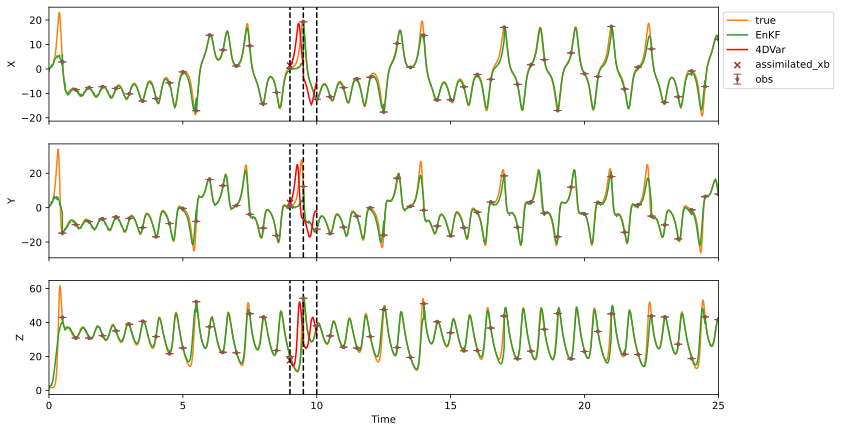

In [92]:
# Plot results
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(time.cpu(), xt.cpu()[k, :], color="#ff7f0e", label='true')
    # ax[k].plot(time.cpu(), lstm_outs.detach().numpy()[k, :], color="#1f77b4", label='lstm')
    ax[k].plot(time.cpu(), xEnKF.cpu()[k, :], color="#2ca02c", label='EnKF')
    ax[k].plot(var4d_times.cpu(), outs.detach().numpy()[k, :], color="red", label='4DVar')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu(), y.cpu()[iobs, :],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        ax[k].scatter(time_obs[start_time_point].cpu(), x0.cpu()[k],
                      color="brown", marker="x", label='assimilated_xb')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    for x in time_obs[start_time_point:end_time_point]:
        ax[k].axvline(x, color="k", linestyle="--")
ax[-1].set_xlabel('Time')
ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()

In [93]:
noda_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - lstm_outs.detach().numpy()[:, time_idxs[0]:time_idxs[-1]+1]) ** 2)
enkf_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2)
var4d_cum_error = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2)
norm = torch.sum(xt[:, time_idxs[0]:time_idxs[-1]+1]**2)
print("Relative errors (RRMSE) in %")
print(f"3-component: {100.0 * torch.sqrt(noda_cum_error / norm):.1f} (No DA)")
print(f"3-component: {100.0 * torch.sqrt(enkf_cum_error / norm):.1f} (EnKF)")
print(f"3-component: {100.0 * torch.sqrt(var4d_cum_error / norm):.1f} (4DVar)\n")
print("Relative errors (MSE) in %")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - lstm_outs.detach().numpy()[:, time_idxs[0]:time_idxs[-1]+1]) ** 2):.1f} (No DA)")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2):.1f} (EnKF)")
print(f"3-component: {100.0 * torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2):.1f} (4DVar)")

Relative errors (RRMSE) in %
3-component: 79.0 (No DA)
3-component: 32.1 (EnKF)
3-component: 67.6 (4DVar)

Relative errors (MSE) in %
3-component: 24146.6 (No DA)
3-component: 3987.6 (EnKF)
3-component: 17705.4 (4DVar)


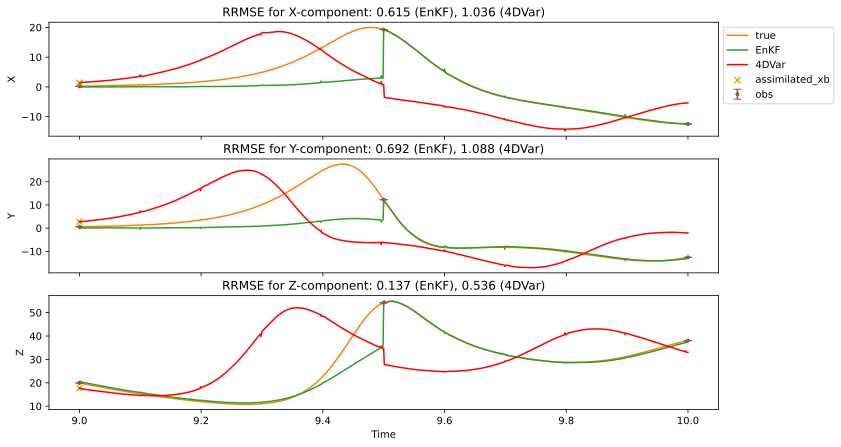

In [94]:
# Plot results
enkf_cum_error_comp = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2, dim=1)
# enkf_cum_error_comp = torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - xEnKF[:, time_idxs[0]:time_idxs[-1]+1]) ** 2, dim=1)
var4d_cum_error_comp = torch.sum((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2, dim=1)
# var4d_cum_error_comp = torch.mean((xt[:, time_idxs[0]:time_idxs[-1]+1] - outs.detach().numpy()) ** 2, dim=1)
norm_comp = torch.sum(xt[:, time_idxs[0]:time_idxs[-1]+1]**2, dim=1)
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)
iobs = 0
for k, comp in enumerate(["X", "Y", "Z"]):
    ax[k].plot(var4d_times.cpu(), xt.cpu()[k, time_idxs[0]:time_idxs[-1]+1], color="#ff7f0e", label='true')
    # ax[k].plot(var4d_times.cpu(), lstm_outs.detach().numpy()[k, time_idxs[0]:time_idxs[-1]+1], color="#1f77b4", label='lstm')
    ax[k].plot(var4d_times.cpu(), xEnKF.cpu()[k, time_idxs[0]:time_idxs[-1]+1], color="#2ca02c", label='EnKF')
    ax[k].plot(var4d_times.cpu(), outs.detach().numpy()[k, :], color="red", label='4DVar')
    if WhichVariablesAreObserved[k] > 0:
        ax[k].errorbar(time_obs.cpu()[start_time_point:end_time_point], y.cpu()[iobs, start_time_point:end_time_point],
                       yerr=sqrt_s.cpu()[iobs, iobs], color="#8c564b",
                       fmt='o', markersize=3, capsize=4, label='obs')
        ax[k].scatter(time_obs[start_time_point].cpu(), x0.cpu()[k],
                      color="y", marker="x", label='assimilated_xb')
        # ax[k].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
        iobs += 1
    ax[k].set_ylabel(comp)
    ax[k].title.set_text(
        # f"RRMSE for {comp}-component: {100 * torch.sqrt(enkf_cum_error_comp[k] / norm_comp[k]):.3f}% (EnKF), {100 * torch.sqrt(var4d_cum_error_comp[k] / norm_comp[k]):.3f}% (4DVar)"
        f"RRMSE for {comp}-component: {torch.sqrt(enkf_cum_error_comp[k] / norm_comp[k]):.3f} (EnKF), {torch.sqrt(var4d_cum_error_comp[k] / norm_comp[k]):.3f} (4DVar)"
    )
ax[-1].set_xlabel('Time')
# ax[-1].set_xlim(time.cpu()[0], time.cpu()[-1])
ax[0].legend(bbox_to_anchor=(1, 1), loc='best', frameon=True)
plt.show()